# Diffusion through Fourier modes

I calculate diffusion on a periodic line. All quantities in this example are dimensionless: position x, time t, concentration c and diffusivity D. The domain length is 2π and D = 1. Fourier wave number k identifies a spatial mode. I use exact propagation of each mode rather than an approximate time-stepping scheme.

I write one part, test it, then continue. Run the cells in order. This short lesson checks the method; it does not replace the complete simulation or establish convergence.

## 1. Define the grid

I omit the repeated endpoint of the periodic interval. I check that the grid spacing times the number of points equals the domain length.

In [1]:
import numpy as np
n = 128
length = 2 * np.pi
spacing = length / n
x = spacing * np.arange(n)
k = 2 * np.pi * np.fft.fftfreq(n, d=spacing)
diffusivity = 1.0
assert np.isclose(n * spacing, length)
assert k[0] == 0
print("Grid points:", n, "spacing:", spacing)

Grid points: 128 spacing: 0.04908738521234052


## 2. Write the initial concentration

The constant term sets the mean. Two cosine terms give two spatial wavelengths. I check the mean and transform the field back before introducing evolution.

In [2]:
initial = 1 + 0.4 * np.cos(x) + 0.2 * np.cos(4 * x)
spectrum = np.fft.fft(initial)
assert abs(initial.mean() - 1) < 1e-12
assert np.max(np.abs(np.fft.ifft(spectrum).real - initial)) < 1e-12
print("Initial mean:", initial.mean())

Initial mean: 1.0


## 3. Evolve one Fourier mode

Diffusion multiplies a Fourier mode by exp(-D k² t). Higher wave numbers decay faster. I check the known concentration profile at one time; this check would catch a missing square on k.

In [3]:
time = 0.3
decay = np.exp(-diffusivity * k**2 * time)
field = np.fft.ifft(spectrum * decay).real
exact = 1 + 0.4 * np.exp(-time) * np.cos(x) + 0.2 * np.exp(-16 * time) * np.cos(4 * x)
assert np.max(np.abs(field - exact)) < 1e-12
assert abs(field.mean() - initial.mean()) < 1e-12
print("Maximum analytical error:", np.max(np.abs(field - exact)))

Maximum analytical error: 2.220446049250313e-16


## 4. Repeat at several times

I keep the same initial spectrum for every time, since each evaluation gives the solution from the initial state. I check mean conservation and the decreasing concentration variation. This is not a time-step convergence study.

Concentration variances: [np.float64(0.1), np.float64(0.08740900361304682), np.float64(0.06631370432580588), np.float64(0.04390628546225194), np.float64(0.010826822658929269)]


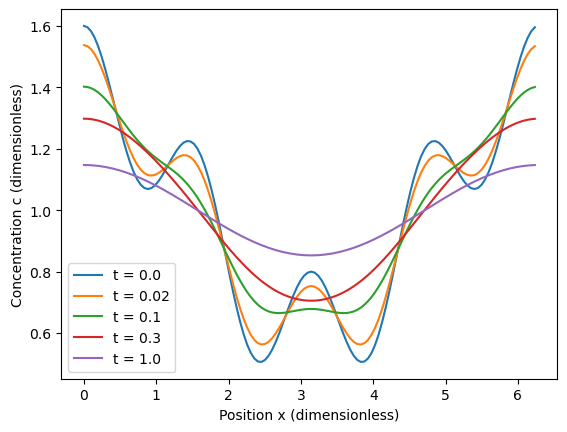

In [4]:
times = [0.0, 0.02, 0.1, 0.3, 1.0]
profiles = []
variation = []
for sample_time in times:
    decay = np.exp(-diffusivity * k**2 * sample_time)
    profile = np.fft.ifft(spectrum * decay).real
    profiles.append(profile)
    variation.append(np.mean((profile - profile.mean())**2))
assert all(abs(profile.mean() - 1) < 1e-12 for profile in profiles)
assert np.all(np.diff(variation) <= 0)
print("Concentration variances:", variation)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for sample_time, profile in zip(times, profiles):
    ax.plot(x, profile, label=f"t = {sample_time}")
ax.set_xlabel("Position x (dimensionless)")
ax.set_ylabel("Concentration c (dimensionless)")
ax.legend()
plt.show()

## Continue with the complete program

The original complete program is `../diffusion.py`. Its parameters, source credits and output commands are retained. These short examples use smaller workloads for learning; they are not a rerun of every result on the website.